# Obtención de datos: PaySim
Descarga y carga del dataset principal (PaySim) desde Kaggle.

In [1]:
!pip install -q kagglehub



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np
import os

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

df["orig_row_id"] = np.arange(len(df), dtype=np.int64)
print(df.shape)
df.head()


(6362620, 12)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_row_id
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,2
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,3
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,4


## Componente 1: construcción de secuencias por cuenta receptora

In [4]:
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib


In [5]:
vc_orig = df["nameOrig"].value_counts()
vc_dest = df["nameDest"].value_counts()
print("nameOrig: max repeticiones =", vc_orig.max(), "| entidades con >1 tx =", (vc_orig > 1).sum())
print("nameDest: max repeticiones =", vc_dest.max(), "| entidades con >1 tx =", (vc_dest > 1).sum())


nameOrig: max repeticiones = 3 | entidades con >1 tx = 9298
nameDest: max repeticiones = 113 | entidades con >1 tx = 459658


In [6]:
MIN_TX = 3
MAX_SEQ_LEN = 50

account_counts = df["nameDest"].value_counts()
valid_accounts = account_counts[account_counts >= MIN_TX].index
df_valid = df[df["nameDest"].isin(valid_accounts)].copy()
print("Cuentas con >=", MIN_TX, "transacciones:", df_valid["nameDest"].nunique())


Cuentas con >= 3 transacciones: 382604


In [7]:
account_labels_full = df_valid.groupby("nameDest")["isFraud"].max()
all_accounts = account_labels_full.index.to_numpy(dtype=object)
all_labels = account_labels_full.to_numpy()
print("Prevalencia natural del universo elegible (MIN_TX>=3):", all_labels.mean())


Prevalencia natural del universo elegible (MIN_TX>=3): 0.012407084086941068


In [8]:
train_accs, temp_accs, train_y, temp_y = train_test_split(
    all_accounts, all_labels, test_size=0.30, stratify=all_labels, random_state=42)
val_pool, test_pool, val_pool_y, test_pool_y = train_test_split(
    temp_accs, temp_y, test_size=0.50, stratify=temp_y, random_state=42)
print("train pool:", len(train_accs), "| val pool:", len(val_pool), "| test pool:", len(test_pool))


train pool: 267822 | val pool: 57391 | test pool: 57391


In [9]:
rng = np.random.default_rng(42)
NEG_PER_POS = 10

train_pos = train_accs[train_y == 1]
train_neg = train_accs[train_y == 0]
n_neg_train = min(len(train_neg), len(train_pos) * NEG_PER_POS)
train_neg_sample = rng.choice(train_neg, size=n_neg_train, replace=False)
train_final = np.concatenate([train_pos, train_neg_sample])
print("Train final:", len(train_final), "| positivos:", len(train_pos), "| negativos:", n_neg_train)


Train final: 36553 | positivos: 3323 | negativos: 33230


In [10]:
VAL_TEST_TARGET_SIZE = 10000

def natural_subsample(pool, pool_y, target_size, seed):
    if len(pool) <= target_size:
        return pool
    sampled, _, _, _ = train_test_split(
        pool, pool_y, train_size=target_size, stratify=pool_y, random_state=seed)
    return sampled

val_final = natural_subsample(val_pool, val_pool_y, VAL_TEST_TARGET_SIZE, seed=1)
test_final = natural_subsample(test_pool, test_pool_y, VAL_TEST_TARGET_SIZE, seed=2)

val_labels_map = account_labels_full.loc[val_final]
test_labels_map = account_labels_full.loc[test_final]
print("Val final:", len(val_final), "prevalencia:", val_labels_map.mean())
print("Test final:", len(test_final), "prevalencia:", test_labels_map.mean())


Val final: 10000 prevalencia: 0.0124
Test final: 10000 prevalencia: 0.0124


In [11]:
split_map = {}
for a in train_final: split_map[a] = "train"
for a in val_final: split_map[a] = "val"
for a in test_final: split_map[a] = "test"

sampled_accounts = list(split_map.keys())
df_sampled = df_valid[df_valid["nameDest"].isin(sampled_accounts)].copy()
df_sampled["split"] = df_sampled["nameDest"].map(split_map)
df_sampled = df_sampled.sort_values(["nameDest", "step", "orig_row_id"]).reset_index(drop=True)
print("Cuentas totales:", len(sampled_accounts), "| transacciones:", len(df_sampled))
print(df_sampled.groupby("split").size())


Cuentas totales: 56553 | transacciones: 588918
split
test     104101
train    382581
val      102236
dtype: int64


In [12]:
TYPE_CATEGORIES = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
type_dummies = df_sampled["type"].apply(lambda t: [1.0 if t == c else 0.0 for c in TYPE_CATEGORIES])
type_matrix = np.array(type_dummies.tolist())

hour = (df_sampled["step"] % 24).to_numpy()
hour_sin = np.sin(2 * np.pi * hour / 24)
hour_cos = np.cos(2 * np.pi * hour / 24)

log_amount = np.log1p(df_sampled["amount"].to_numpy())
log_oldbalorg = np.log1p(df_sampled["oldbalanceOrg"].to_numpy())
log_newbalorg = np.log1p(df_sampled["newbalanceOrig"].to_numpy())
log_oldbaldest = np.log1p(df_sampled["oldbalanceDest"].to_numpy())
log_newbaldest = np.log1p(df_sampled["newbalanceDest"].to_numpy())


In [13]:

g = df_sampled.groupby("nameDest", sort=False)
delta_step = g["step"].diff().fillna(0.0)
log_delta_step = np.log1p(delta_step.to_numpy())

steps_arr = df_sampled["step"].to_numpy()
amounts_arr = df_sampled["amount"].to_numpy()
accounts_arr = df_sampled["nameDest"].to_numpy()

tx_count_24h = np.zeros(len(df_sampled), dtype="float64")
tx_count_7d = np.zeros(len(df_sampled), dtype="float64")
amount_sum_24h = np.zeros(len(df_sampled), dtype="float64")
amount_sum_7d = np.zeros(len(df_sampled), dtype="float64")

for _, idx in df_sampled.groupby("nameDest", sort=False).indices.items():
    idx = np.asarray(idx)
    s = steps_arr[idx]
    a = amounts_arr[idx]
    cum_amount = np.concatenate([[0.0], np.cumsum(a)])
    start_24h = np.searchsorted(s, s - 24, side="left")
    start_7d = np.searchsorted(s, s - 168, side="left")
    positions = np.arange(len(idx))
    tx_count_24h[idx] = positions - start_24h + 1
    tx_count_7d[idx] = positions - start_7d + 1
    amount_sum_24h[idx] = cum_amount[positions + 1] - cum_amount[start_24h]
    amount_sum_7d[idx] = cum_amount[positions + 1] - cum_amount[start_7d]

log_tx_count_24h = np.log1p(tx_count_24h)
log_tx_count_7d = np.log1p(tx_count_7d)
log_amount_sum_24h = np.log1p(amount_sum_24h)
log_amount_sum_7d = np.log1p(amount_sum_7d)


In [14]:
raw_features = np.column_stack([
    log_amount, log_oldbalorg, log_newbalorg, log_oldbaldest, log_newbaldest,
    log_delta_step, log_tx_count_24h, log_tx_count_7d, log_amount_sum_24h, log_amount_sum_7d,
    hour_sin, hour_cos, type_matrix,
])
FEATURE_NAMES = [
    "log_amount", "log_oldbalanceOrg", "log_newbalanceOrig",
    "log_oldbalanceDest", "log_newbalanceDest",
    "log_delta_step", "log_tx_count_24h", "log_tx_count_7d",
    "log_amount_sum_24h", "log_amount_sum_7d",
    "hour_sin", "hour_cos",
] + TYPE_CATEGORIES
N_CONTINUOUS = 10
print("Shape de features por transacción:", raw_features.shape, "| features:", len(FEATURE_NAMES))


Shape de features por transacción: (588918, 17) | features: 17


In [15]:
train_mask = (df_sampled["split"] == "train").to_numpy()
scaler = StandardScaler()
scaler.fit(raw_features[train_mask][:, :N_CONTINUOUS])

norm_features = raw_features.copy()
norm_features[:, :N_CONTINUOUS] = scaler.transform(raw_features[:, :N_CONTINUOUS])


In [16]:
N_FEATURES = norm_features.shape[1]
n_accounts = len(sampled_accounts)
sequences = np.zeros((n_accounts, MAX_SEQ_LEN, N_FEATURES), dtype="float32")
seq_lengths = np.zeros(n_accounts, dtype="int32")
final_labels = np.zeros(n_accounts, dtype="float32")

account_to_idx = {a: i for i, a in enumerate(sampled_accounts)}
row_account = df_sampled["nameDest"].to_numpy()

per_account_rows = {}
for row_idx, a in enumerate(row_account):
    per_account_rows.setdefault(a, []).append(row_idx)

transaction_map_rows = []
for a, rows in per_account_rows.items():
    i = account_to_idx[a]
    L = min(len(rows), MAX_SEQ_LEN)
    kept_rows = rows[:L]
    seq_lengths[i] = L
    sequences[i, :L, :] = norm_features[kept_rows]

    final_labels[i] = df_sampled.iloc[kept_rows]["isFraud"].max()

    for pos, row_idx in enumerate(kept_rows):
        r = df_sampled.iloc[row_idx]
        transaction_map_rows.append((
            a, pos, int(r["orig_row_id"]), int(r["step"]), r["nameOrig"], r["nameDest"],
            float(r["amount"]), r["type"], int(r["isFraud"]), r["split"],
        ))

n_truncated = int((seq_lengths == MAX_SEQ_LEN).sum())
print("Shape de secuencias:", sequences.shape)
print(f"Cuentas truncadas al límite de {MAX_SEQ_LEN}: {n_truncated} de {n_accounts} "
      f"({100 * n_truncated / n_accounts:.2f}%)")
n_label_changed = int((final_labels != account_labels_full.loc[sampled_accounts].to_numpy()).sum())
print("Cuentas cuyo label cambió por el truncado:", n_label_changed)


Shape de secuencias: (56553, 50, 17)
Cuentas truncadas al límite de 50: 182 de 56553 (0.32%)
Cuentas cuyo label cambió por el truncado: 4


In [17]:
account_split = pd.Series(split_map)
meta = pd.DataFrame({
    "account_id": sampled_accounts,
    "label": final_labels,
    "split": account_split.loc[sampled_accounts].to_numpy(),
    "seq_len": seq_lengths,
})

transaction_map = pd.DataFrame(transaction_map_rows, columns=[
    "account_id", "position", "orig_row_id", "step", "nameOrig", "nameDest",
    "amount", "type", "isFraud", "split",
])

meta.to_csv("C1_output_meta.csv", index=False)
np.save("C1_output_sequences.npy", sequences)
transaction_map.to_csv("C1_output_transaction_map.csv", index=False)
with open("C1_output_feature_names.json", "w") as f:
    json.dump(FEATURE_NAMES, f)

joblib.dump({"scaler": scaler, "n_continuous": N_CONTINUOUS, "feature_names": FEATURE_NAMES},
            "C1_output_scaler.joblib")
meta.head()


,account_id,label,split,seq_len
0,C187881338,1.0,train,10
1,C866867675,1.0,train,19
2,C1762365059,1.0,train,3
3,C876852627,1.0,train,4
4,C154560289,1.0,train,14


In [18]:
check_row = transaction_map.iloc[0]
original_row = df.loc[check_row["orig_row_id"]]
assert original_row["nameDest"] == check_row["nameDest"]
assert original_row["step"] == check_row["step"]
assert abs(original_row["amount"] - check_row["amount"]) < 1e-6
print("orig_row_id verificado: apunta correctamente a la fila original de PaySim.")


orig_row_id verificado: apunta correctamente a la fila original de PaySim.


### Verificación

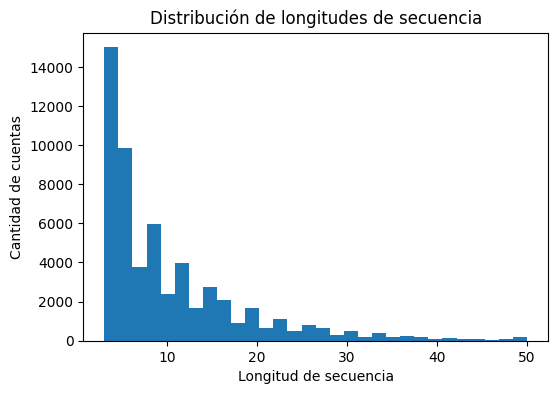

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(meta["seq_len"], bins=30)
plt.xlabel("Longitud de secuencia")
plt.ylabel("Cantidad de cuentas")
plt.title("Distribución de longitudes de secuencia")
plt.show()


Proporción global de clases (0=normal, 1=sospechoso):
label
0.0    0.936926
1.0    0.063074
Name: proportion, dtype: float64

Prevalencia por split (train está submuestreado 10:1; val/test conservan la del universo elegible):
split
test     0.0124
train    0.0908
val      0.0124
Name: label, dtype: float32


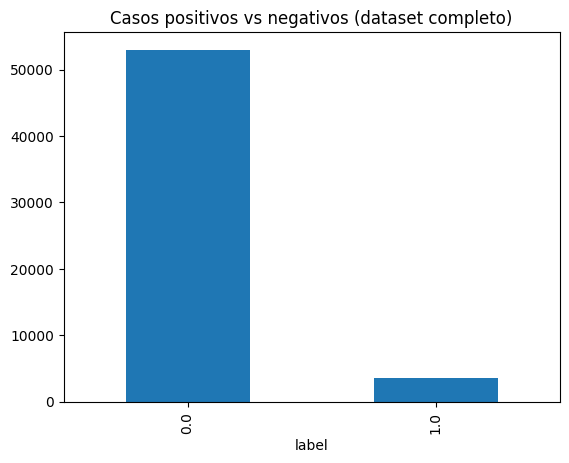

In [20]:
print("Proporción global de clases (0=normal, 1=sospechoso):")
print(meta["label"].value_counts(normalize=True))
print()
print("Prevalencia por split (train está submuestreado 10:1; val/test conservan la del universo elegible):")
print(meta.groupby("split")["label"].mean())
meta["label"].value_counts().plot(kind="bar", title="Casos positivos vs negativos (dataset completo)")
plt.show()


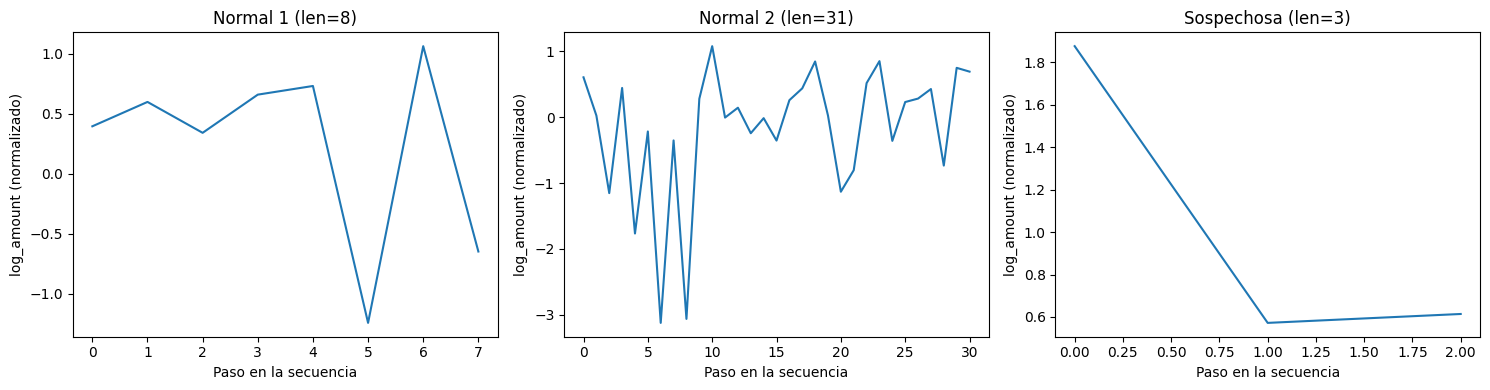

In [21]:
normal_idx = meta[meta["label"] == 0].sample(2, random_state=1).index
fraud_idx = meta[meta["label"] == 1].sample(1, random_state=1).index
example_idx = list(normal_idx) + list(fraud_idx)
example_titles = ["Normal 1", "Normal 2", "Sospechosa"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, title in zip(axes, example_idx, example_titles):
    L = seq_lengths[idx]
    ax.plot(sequences[idx, :L, 0])
    ax.set_title(f"{title} (len={L})")
    ax.set_xlabel("Paso en la secuencia")
    ax.set_ylabel("log_amount (normalizado)")
plt.tight_layout()
plt.show()
